In [11]:
import os
import cv2
import numpy as np
from skimage.metrics import structural_similarity as ssim
from tqdm import tqdm

In [ ]:


def read_frame(cap, time_s):
    """Lit une frame spécifique (en secondes) depuis une vidéo."""
    cap.set(cv2.CAP_PROP_POS_MSEC, time_s * 1000)
    ret, frame = cap.read()
    if not ret:
        return None
    frame = cv2.resize(frame, (320, 180))  # petite taille = plus rapide
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    return gray

def video_duration(path):
    cap = cv2.VideoCapture(path)
    fps = cap.get(cv2.CAP_PROP_FPS)
    frame_count = cap.get(cv2.CAP_PROP_FRAME_COUNT)
    duration = frame_count / fps
    cap.release()
    return duration

def find_best_offset(video1_path, video2_path, search_range=10, step=0.5):
    """
    Cherche le décalage (en secondes) entre deux vidéos en comparant visuellement les frames.
    search_range = nombre de secondes à explorer (±)
    step = intervalle d'échantillonnage en secondes
    """
    cap1 = cv2.VideoCapture(video1_path)
    cap2 = cv2.VideoCapture(video2_path)

    duration1 = video_duration(video1_path)
    duration2 = video_duration(video2_path)
    min_duration = min(duration1, duration2)

    times = np.arange(0, min_duration, step)
    ref_frames = [read_frame(cap1, t) for t in times]

    best_offset = 0
    best_score = -1

    print("🔍 Recherche du meilleur alignement...")
    for offset in tqdm(np.arange(-search_range, search_range, step)):
        scores = []
        for i, t in enumerate(times):
            f1 = ref_frames[i]
            f2 = read_frame(cap2, t + offset)
            if f1 is None or f2 is None:
                continue
            score = ssim(f1, f2)
            scores.append(score)
        if scores:
            mean_score = np.mean(scores)
            if mean_score > best_score:
                best_score = mean_score
                best_offset = offset

    cap1.release()
    cap2.release()
    return best_offset, best_score

In [13]:
video1 = "/Users/bapti/Projets/REDEV/ML_walkability/data/P01/raw/Video.mp4"
video2 = "/Users/bapti/Projets/REDEV/ML_walkability/data/P02/raw/Video.mp4"
os.path.exists(video1)

True

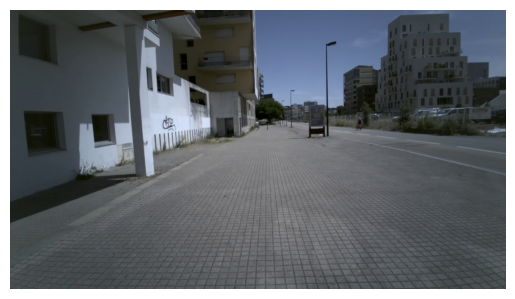

In [75]:
cap = cv2.VideoCapture(video1)
frame_idx = 800
cap.set(cv2.CAP_PROP_POS_FRAMES, frame_idx)
ret, frame = cap.read()
if ret:
    frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    plt.imshow(frame_rgb)
    plt.axis("off")
    plt.show()
frame = cv2.resize(frame, (320, 180))
solo = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)


In [97]:
cap1 = cv2.VideoCapture(video1)
cap2 = cv2.VideoCapture(video2)

duration1 = video_duration(video1)
duration2 = video_duration(video2)
min_duration = min(duration1, duration2)

times = np.linspace(0, 60, 500)
ref = read_frame(cap1, 45)
other = [read_frame(cap2, t) for t in times]

In [98]:
scores = []
for frame in other:
    score = ssim(ref, frame)
    scores.append(score)

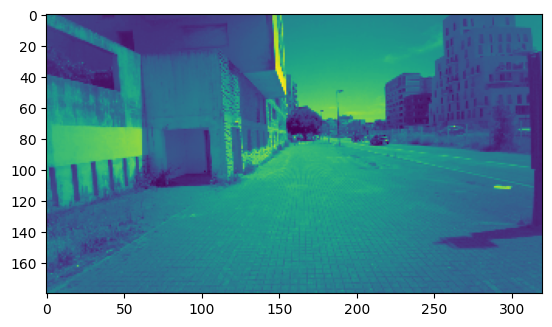

In [99]:
import matplotlib.pyplot as plt
plt.imshow(ref)

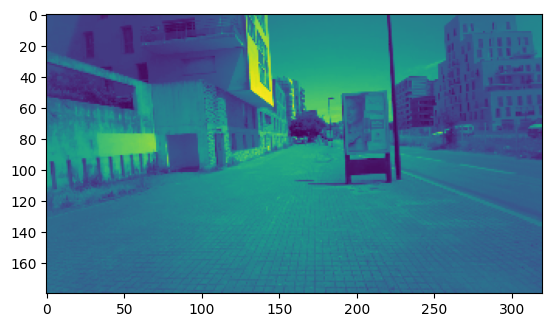

In [100]:
best = max(range(len(scores)), key=lambda x: scores[x])
plt.imshow(other[best])